In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,StandardScaler
import seaborn as sns
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')

In [4]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [5]:
X = df.drop(columns='Loan_Approved')
y = df.Loan_Approved

In [6]:
xtrain,xtest,ytrain,ytest = train_test_split(
    X,y,
    random_state=42,
    train_size=0.8
)

In [7]:
X.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [8]:
num_cols = X.select_dtypes(include='number').columns
obj_cols = X.select_dtypes(include='object').columns

<Axes: >

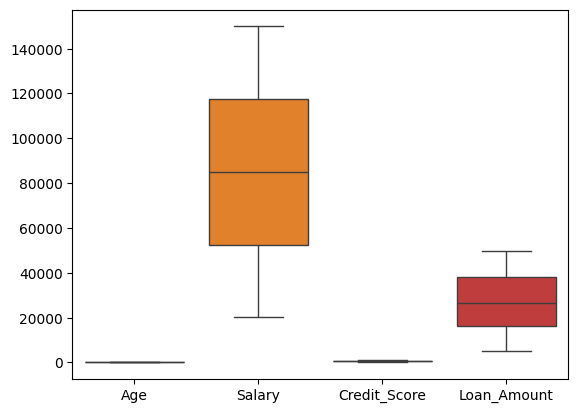

In [9]:
sns.boxplot(X[num_cols])

In [10]:
X[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

Preprocessing Techniques

-Scaling
-Encoding
why scaling?

Feature (numerical)Cols values are in different range(scale).So we can use scaling to give equal importance for all the feature cols

why encoding?

Algorithms can understand only numbers not strings

Which Scaling and Encoding Techniques we can use for this ?

Scaling - 1) MinMaxScaler,2)StandardScaler

Encoding

Loan_Term -4, Employment_Status -3, Residence_Type -3, Previous_Default -2

Uniques values are less so we can use OneHotEncoder

In [11]:
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)
scaling  = MinMaxScaler()
# model = LogisticRegression(penalty='l1',solver='liblinear')
model = LogisticRegression(penalty=None)

In [12]:
# model.fit(xtrain,ytrain)

In [13]:
#Xtrain
xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
# xtrain[obj_cols] = encoder.fit_transform(xtrain[obj_cols])
encoded_values = encoder.fit_transform(xtrain[obj_cols])
encoded_columns = encoder.get_feature_names_out()
xtrain[encoded_columns] = encoded_values
xtrain.drop(columns=obj_cols,inplace=True)

In [14]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [15]:
#Xtest
xtest[num_cols] = scaling.transform(xtest[num_cols])
# xtest[obj_cols] = encoder.fit_transform(xtest[obj_cols])
encoded_values = encoder.transform(xtest[obj_cols])
xtest[encoded_columns] = encoded_values
xtest.drop(columns=obj_cols,inplace=True)

In [16]:
model.fit(xtrain,ytrain)

LogisticRegression(penalty=None)

In [17]:
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix

DATA EVALUATION

In [18]:
ytrain_pred = model.predict(xtrain)
matrix = confusion_matrix(ytrain,ytrain_pred)

In [19]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

In [20]:
precision_score(ytrain,ytrain_pred,pos_label='Yes')

0.5471698113207547

In [21]:
predicted_yes = np.sum(matrix[:,1])
predicted_no = np.sum(matrix[:,0])

Conclusion :

-Out of all the predicted `Yes` labels(425),54% labels are correctly predicted as `Yes`

- Out of all the predicted `Yes` labels(425),46% labels are wrongly  predicted as `Yes`

In [22]:
precision_score(ytrain,ytrain_pred,pos_label='No')

0.5452127659574468

Conclusion :

-Out of all the predicted `No` labels(375),54% labels are correctly predicted as `No`

- Out of all the predicted `No` labels(375),46% labels are wrongly  predicted as `No`

In [23]:
recall_score(ytrain,ytrain_pred,pos_label='Yes')

0.575682382133995

Conclusion :

-Out of all the actual `Yes` labels(403),57% labels are correctly predicted as `Yes`

- Out of all the actual `Yes` labels(403),43% labels are wrongly  predicted as `No`

In [24]:
recall_score(ytrain,ytrain_pred,pos_label='No')

0.5163727959697733

Conclusion :

-Out of all the actual `No` labels(397),51% labels are correctly predicted as `No`

- Out of all the actual `No` labels(397),49% labels are wrongly  predicted as `Yes`

In [25]:
accuracy_score(ytrain,ytrain_pred)

0.54625

Conclusion :

Out of all the samples(800),54.75% samples are correctly predicted

Final Conclusion :

Model performance on train data is bad,so model is not learned train data patterns properly

Model is underfit (high bias and low var) test data 50% model is not capture train and test data is not captured properly

In [26]:
from sklearn.metrics import classification_report

In [27]:
print(classification_report(ytrain, ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



overalll 53% are no label(f1-score)

recall-opposite (yes or no)

precision-same (yes or no)

accuracy-overall score(800)

macro-average of all Metric score(precision+recall//2)=(0.55+0.55//2) --->overall conclusion for precision score macro f1-score used to check in imbalanced data (f1 is combo of precison and recall)

weighted avg-avearage of --->overall

In [28]:
print(classification_report(ytrain, ytrain_pred))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



In [29]:
X.corr(numeric_only=True)


num_cols = X.select_dtypes(include='number').columns
obj_cols = X.select_dtypes(include='object').columns

In [30]:
X[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

In [31]:
df.head(5)

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [32]:
onehot_col = ["Loan_Term","Residence_Type","Employment_Status","Previous_Default"]

ordinal_col = ["person_education"]
nums=['Age','Salary','Credit_Score','Loan_Amount']


model=LogisticRegression()
preprocessing = ColumnTransformer(
    transformers=[
        ("onehot",   OneHotEncoder(handle_unknown="ignore", sparse_output=False),  onehot_col),   
        ("scaler",  MinMaxScaler(), nums)
    ],
    remainder="passthrough"
)

In [33]:
model=LogisticRegression()

In [34]:
main_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(random_state=42,penalty=None))
    ])

In [35]:
grid_search_cv=GridSearchCV(
    estimator=main_pipeline,
    cv=3,
    param_grid={
        'model__solver':['liblinear','saga'],            
        'model__class_weight':[None,'balanced'],
        'model__max_iter':[100,200]
        },
    verbose=1)


 #'model__criterion':['gini','entropy'], ----------->Go inside model and take value(if we use pipeline use model_ _
grid_search_cv.fit(xtrain,ytrain)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


ValueError: 
All the 24 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
24 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\AVANIY\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\indexes\base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas\\_libs\\hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas\\_libs\\hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'Loan_Term'

The above exception was th